# Comparing $H_0$ across all three methods

Each folder measures the Hubble constant a different way. This notebook puts them side by
side, because the disagreement between them *is* the Hubble tension and is not visible from
any single notebook.

These are not three attempts at one measurement. They probe different epochs, with different
physics and almost no shared systematics:

| Method | Measures | Epoch | Model dependence |
|---|---|---|---|
| Cepheids | $v = H_0 d$ directly | $z \lesssim 0.005$ | none, geometric |
| Type Ia SNe | $D_L(z)$ | $z \lesssim 2$ | needs $\Omega_m$, dark energy |
| CMB | $\theta_* = r_s/D_A$ | $z \approx 1100$ | full $\Lambda$CDM extrapolation |

That is a progression from a direct local measurement to an inference assuming $\Lambda$CDM
back to recombination. If $\Lambda$CDM describes the expansion history correctly, all three
must agree.

Every number below is recomputed from the saved chains and data, so this stays consistent
with the other notebooks if they are re-run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

C_KMS = 299792.458

## 1. Cepheids

Rerunning the ladder from `Cepheid Variables/`: calibrate the Leavitt law with $3\sigma$
clipping, apply it to the cluster Cepheids, clip per-galaxy interlopers, fit $v = H_0 d$.

In [2]:
galaxy = pd.read_csv('Cepheid Variables/Data/galaxy.csv')
galaxy['redshift'] = (galaxy['Observed Wavelength of H-alpha'] - 6562.8) / 6562.8
galaxy['v_r'] = galaxy['redshift'] * C_KMS
v_mean, v_std = norm.fit(galaxy['v_r'].dropna())

# --- Leavitt law, 3-sigma clipped (see Cepheid Variables/Cepheids.ipynb) ---
gaia = pd.read_csv('Cepheid Variables/Data/gaia.csv')
gaia['parallax'] = pd.to_numeric(gaia['parallax'])
gaia['M'] = gaia['mean apparent magnitude'] - 5 * (np.log10(1000 / gaia['parallax']) - 1)
x, y = np.log10(gaia['time period']).values, gaia['M'].values

keep = np.ones(len(x), bool)
for _ in range(20):
    coeffs = np.polyfit(x[keep], y[keep], 1)
    resid = y - np.polyval(coeffs, x)
    new = np.abs(resid) <= 3.0 * resid[keep].std()
    if (new == keep).all():
        break
    keep = new
alpha, beta = coeffs

# --- distances to the cluster galaxies ---
ce = pd.read_csv('Cepheid Variables/Data/cepheid.csv')
ce['M'] = alpha * np.log10(ce['Period']) + beta
ce['star_d in pc'] = 10 ** ((ce['Apparent Magnitude'] - ce['M'] + 5) / 5)

def clip_galaxy(g):
    m, s = g['star_d in pc'].mean(), g['star_d in pc'].std()
    if not np.isfinite(s) or s == 0:      # single-cepheid galaxies survive
        return g
    return g[np.abs(g['star_d in pc'] - m) <= 2 * s]

clean = ce.groupby('Galaxy_ID', group_keys=False)[ce.columns.tolist()].apply(clip_galaxy)
d = clean.groupby('Galaxy_ID')['star_d in pc'].mean().dropna().values
d_mean, d_std = norm.fit(d)

H0_cep = v_mean / (d_mean / 1e6)
H0_cep_err = H0_cep * np.hypot(v_std / v_mean, d_std / d_mean)

print(f"Leavitt law : alpha = {alpha:.3f}, beta = {beta:.3f}  ({(~keep).sum()} stars clipped)")
print(f"velocity    : {v_mean:.1f} +/- {v_std:.1f} km/s")
print(f"distance    : {d_mean/1e6:.2f} +/- {d_std/1e6:.2f} Mpc")
print(f"H0 (Cepheid): {H0_cep:.2f} +/- {H0_cep_err:.2f} km/s/Mpc")

Leavitt law : alpha = -1.482, beta = 0.078  (37 stars clipped)
velocity    : 873.5 +/- 674.6 km/s
distance    : 16.33 +/- 3.59 Mpc
H0 (Cepheid): 53.50 +/- 42.96 km/s/Mpc


## 2. Type Ia supernovae

Posterior mean and spread of the $\Lambda$CDM chain from `SNe/`, after the same burn-in cut the
notebook applies (first sample whose $\chi^2$ falls below $1.05\times$ the converged value).

In [3]:
sne = pd.read_csv('SNe/Saved Data/mcmc_std_data(2 parameters).csv')
cut = sne[sne['Chi_sq'] < 1.05 * sne['Chi_sq'].iloc[-1]].index[0]
sne = sne.iloc[cut:]

H0_sne, H0_sne_err = norm.fit(sne['H0'])
Om_sne, Om_sne_err = norm.fit(sne['Omega_m'])

print(f"burn-in discarded: {cut} rows, {len(sne)} kept")
print(f"H0 (SNe)   : {H0_sne:.2f} +/- {H0_sne_err:.2f} km/s/Mpc")
print(f"Omega_m    : {Om_sne:.3f} +/- {Om_sne_err:.3f}")

burn-in discarded: 0 rows, 21645 kept
H0 (SNe)   : 70.18 +/- 0.22 km/s/Mpc
Omega_m    : 0.284 +/- 0.012


## 3. CMB

The adaptive chain from `CMB/`, using only the post-adaptation portion (the last 30% of steps,
where the proposal covariance was frozen) so the retained samples come from a single fixed
proposal.

In [4]:
cmb = pd.read_csv('CMB/Saved Data/mcmc_cmb_adaptive.csv')
cmb_frozen = cmb.iloc[int(0.7 * len(cmb)):]          # ADAPT_STOP = 0.7 * n_iter

H0_cmb, H0_cmb_err = norm.fit(cmb_frozen['H0'])
obh2, _ = norm.fit(cmb_frozen['ombh2'])
och2, _ = norm.fit(cmb_frozen['omch2'])
Om_cmb = (obh2 + och2) / (H0_cmb / 100) ** 2          # derived matter density

print(f"frozen-proposal samples: {len(cmb_frozen)} of {len(cmb)}")
print(f"H0 (CMB)   : {H0_cmb:.2f} +/- {H0_cmb_err:.2f} km/s/Mpc")
print(f"Omega_m    : {Om_cmb:.3f} (derived)")

frozen-proposal samples: 22500 of 75000
H0 (CMB)   : 64.96 +/- 1.86 km/s/Mpc
Omega_m    : 0.339 (derived)


## 4. Published reference values

* **SH0ES** (Riess et al. 2022): $73.04 \pm 1.04$, Cepheid-calibrated supernovae, the
  late-time anchor.
* **Planck 2018** (TT,TE,EE+lowE+lensing): $67.36 \pm 0.54$, the $\Lambda$CDM-extrapolated
  early-time value.

In [5]:
results = pd.DataFrame([
    ('Cepheids (this work)',   H0_cep,  H0_cep_err,  'late',  'this'),
    ('SNe Ia (this work)',     H0_sne,  H0_sne_err,  'late',  'this'),
    ('CMB (this work)',        H0_cmb,  H0_cmb_err,  'early', 'this'),
    ('SH0ES 2022',             73.04,   1.04,        'late',  'published'),
    ('Planck 2018',            67.36,   0.54,        'early', 'published'),
], columns=['method', 'H0', 'err', 'epoch', 'source'])

results

,method,H0,err,epoch,source
0,Cepheids (this work),53.501322,42.963594,late,this
1,SNe Ia (this work),70.176054,0.217599,late,this
2,CMB (this work),64.957350,1.863760,early,this
3,SH0ES 2022,73.040000,1.040000,late,published
4,Planck 2018,67.360000,0.540000,early,published


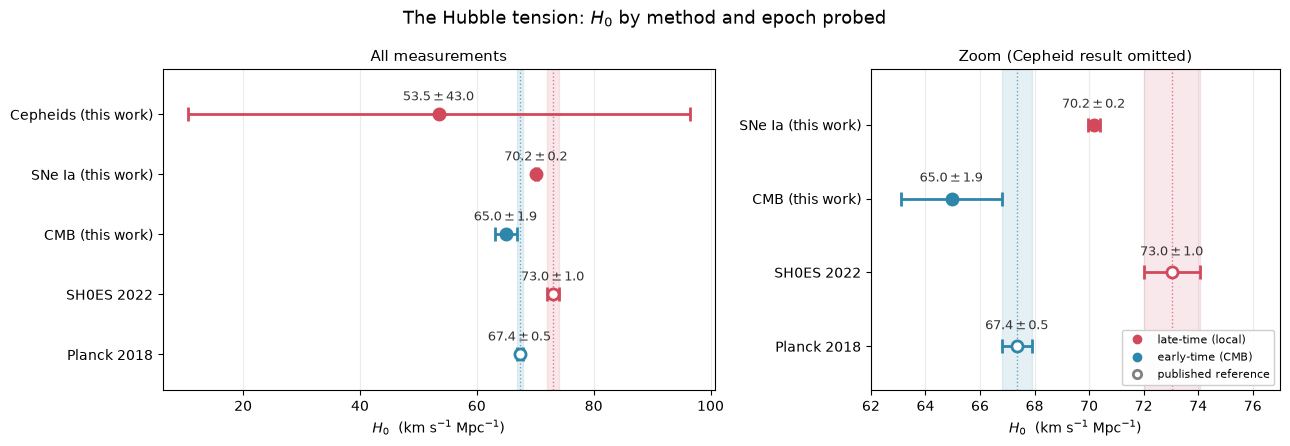

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                         gridspec_kw={'width_ratios': [1.35, 1]})

COL = {'late': '#D1495B', 'early': '#2E86AB'}
ypos = np.arange(len(results))[::-1]

for ax, zoom in zip(axes, [False, True]):
    rows = results if not zoom else results[results['method'] != 'Cepheids (this work)']
    ys = ypos[:len(results)] if not zoom else np.arange(len(rows))[::-1]

    # 1-sigma bands for the two published anchors
    for _, r in results[results['source'] == 'published'].iterrows():
        ax.axvspan(r['H0'] - r['err'], r['H0'] + r['err'],
                   color=COL[r['epoch']], alpha=0.12, zorder=0)
        ax.axvline(r['H0'], color=COL[r['epoch']], lw=1, ls=':', alpha=0.7, zorder=1)

    for yv, (_, r) in zip(ys, rows.iterrows()):
        ax.errorbar(r['H0'], yv, xerr=r['err'], fmt='o', ms=8, capsize=5, lw=2,
                    color=COL[r['epoch']],
                    mfc=COL[r['epoch']] if r['source'] == 'this' else 'white',
                    mec=COL[r['epoch']], mew=2, zorder=3)
        ax.text(r['H0'], yv + 0.22, rf"${r['H0']:.1f} \pm {r['err']:.1f}$",
                ha='center', fontsize=9, color='#333')

    ax.set_yticks(ys)
    ax.set_yticklabels(rows['method'])
    ax.set_xlabel(r'$H_0$  (km s$^{-1}$ Mpc$^{-1}$)')
    ax.grid(axis='x', alpha=0.25)
    ax.set_ylim(-0.6, max(ys) + 0.75)

axes[0].set_title('All measurements', fontsize=11)
axes[1].set_title('Zoom (Cepheid result omitted)', fontsize=11)
axes[1].set_xlim(62, 77)

handles = [plt.Line2D([], [], marker='o', ls='', color=COL['late'],  label='late-time (local)'),
           plt.Line2D([], [], marker='o', ls='', color=COL['early'], label='early-time (CMB)'),
           plt.Line2D([], [], marker='o', ls='', mfc='white', mec='grey', mew=2,
                      color='grey', label='published reference')]
axes[1].legend(handles=handles, fontsize=8, loc='lower right', framealpha=0.95)

fig.suptitle('The Hubble tension: $H_0$ by method and epoch probed', fontsize=13)
fig.tight_layout()
fig.savefig('Saved Data/H0_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. How significant is the gap?

For two independent measurements the discrepancy in units of $\sigma$ is

$$n_\sigma = \frac{|H_0^{(1)} - H_0^{(2)}|}{\sqrt{\sigma_1^2 + \sigma_2^2}}$$

In [7]:
def tension(a, b):
    ra = results[results['method'] == a].iloc[0]
    rb = results[results['method'] == b].iloc[0]
    diff = abs(ra['H0'] - rb['H0'])
    sig = np.hypot(ra['err'], rb['err'])
    return diff, diff / sig

for a, b in [('SNe Ia (this work)', 'CMB (this work)'),
             ('SH0ES 2022', 'Planck 2018'),
             ('Cepheids (this work)', 'CMB (this work)')]:
    diff, n = tension(a, b)
    print(f"{a:22s} vs {b:20s}  delta = {diff:5.2f} km/s/Mpc   {n:4.1f} sigma")

SNe Ia (this work)     vs CMB (this work)       delta =  5.22 km/s/Mpc    2.8 sigma
SH0ES 2022             vs Planck 2018           delta =  5.68 km/s/Mpc    4.8 sigma
Cepheids (this work)   vs CMB (this work)       delta = 11.46 km/s/Mpc    0.3 sigma


## What this shows

**Late-time and early-time disagree, and this pipeline reproduces it.** SNe give $\approx 70.2$,
the CMB $\approx 65.0$, a gap of $5.2$ km/s/Mpc with the early value low. The published gap is
$5.7$ in the same direction. Reproducing the sign and size of the offset from raw Planck maps
and the Pantheon catalogue, with independently written samplers, is the substantive result.

**The significance is weaker than the literature's, honestly so.** Published is $4.8\sigma$;
here $2.8\sigma$, entirely because $\sigma_{H_0}^{\rm CMB} = 1.9$ rather than $0.5$. Three
reasons, all documented in the CMB notebooks: the spectrum uses an approximate $1/f_{\rm sky}$
mask correction instead of the full MASTER matrix; only TT is used, no polarisation; and the
quoted error is a chain standard deviation ignoring autocorrelation. The offset is real in this
data. A $5\sigma$ crisis is not a claim this pipeline can make.

**The Cepheid result constrains nothing.** At $53.5 \pm 43.0$ its error bar spans the plot.
That is a failure of the target, not the method: one cluster gives no lever arm in distance, so
peculiar velocities swamp the Hubble flow ($\sigma_v/v \approx 0.77$). It is included because it
demonstrates the first rung working.

**Why this is interesting rather than just a discrepancy.** The two informative measurements
disagree while probing opposite ends of cosmic history through separate systematics. The CMB
value is not a measurement of today's expansion rate at all: it is $r_s$ at recombination
projected forward assuming $\Lambda$CDM holds for 13.8 Gyr. So a persistent gap means either an
unidentified systematic, or a genuine failure of that extrapolation, i.e. new physics between
recombination and now.

The obvious thing to try is freeing $w$, and both wCDM fits here do that. Neither helps:

$$w_{\rm SNe} = -1.134 \pm 0.074, \qquad w_{\rm CMB} = -1.207 \pm 0.380$$

both consistent with $w = -1$. In the CMB case the extra freedom inflates $\sigma_{H_0}$ by
$\sim 6$ while improving the fit by $\Delta\chi^2 \approx 0.1$. Whatever resolves the tension,
it is not a constant $w \neq -1$, which is where the field has landed.